## import

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

In [ ]:
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AF2pp


## train

In [54]:
modelname = 'varp1_noreward'
# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
modeli = 0

for attcost in [-1.6]:
    for facost in [-50,]:
        for reward in [3000]:
            # other env params
            env_param = [0, reward, attcost, .25, facost, 0, 0]
            seed=0
            thismodel = f'seed_{seed}_{modelname}_{modeli}'
            print(thismodel)
            for seed in range(n_seed):
                # set seed
                np.random.seed(seed)
                task = AF2pp(spec={'agent': {'lick_cost': env_param[0],
                                            'food_reward': env_param[1],
                                            'attention_cost_coeff': env_param[2],
                                            'attention_cost_temp': env_param[3],
                                            'penalty_cost': env_param[4],
                                            'iti_cost': env_param[5],
                                            'time_in_game_reward': env_param[6]}})
            
                taskbelief = FuncBeliefModel(env=task, rng=1)
                model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                            clip_range=0.1, ent_coef=0.01, tensorboard_log=f"runs/{modelname}",)
                

seed_0_varp1_noreward_0


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [55]:
model.learn(total_timesteps=epoch_size,
            tb_log_name=thismodel,
            reset_num_timesteps=False,
            )
# model.save(f'ycstore/{thismodel}')

# eval
# collect trial data
task.food_reward_idx=0
import multiprocess
no_episodes=3333
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                            num_steps=100000, deterministic=True)
    return episode

with multiprocess.Pool(processes=6) as pool:
    all_episode_data = pool.map(eval_wrapper, range(no_episodes))

plotname=thismodel
all_reward_res=[]# k: v = foodreward: this food reward res

for episode in all_episode_data:
    r=episode['trial_food_reward_idx']
    p1p2=episode['p1p2']
    
    att_time_list,lick_time_list=[],[]
    att_time_list.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
    # attention_prob, lick_prob = get_att_lick_probs(episode, agent)
    # attention_prob_list.append(attention_prob)
    # lick_prob_list.append(lick_prob)
    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))

    all_reward_res.append((r,p1p2[0], p1p2[1],att_time_list, lick_time_list))
import pandas as pd
df = pd.DataFrame(all_reward_res,columns = ['reward', 'p1', 'p2', 'att_time', 'lick_time'])
df


KeyboardInterrupt: 

In [53]:
task.reset()
task.obs_certainity_possible, task.p1, task.p2

(array([0.65, 0.7 ]), 0.6500000000000001, 0.7000000000000002)

In [ ]:

for r in df['reward'].unique():
    for p1 in df['p1'].unique():
        for p2 in list(df['p2'].unique())[2:3]:
            att_seq_list = df[(df.reward==r)&(df.p1==p1)&(df.p2==p2)].att_time
            # att_seq_list=df.att_time
            att_seq_list=att_seq_list.tolist()
            att_seq_list=[(a[0]).astype('float').tolist() for a in att_seq_list]
            sorted_list_of_lists = sorted(att_seq_list, key=len)
            sequences = sorted_list_of_lists[-1000:-1] # Choosing what range of trial lengths to use. Could modify to be more consistent.
            normalized_sequences = []
            max_length = 1
            for sequence in sequences:
                normalized_seq = np.array(sequence)
                if not np.isnan(normalized_seq.any()):
                    normalized_sequences.append(normalized_seq)
                    max_length = max(max_length, len(normalized_seq))    
                
            padded_sequences = []
            for seq in normalized_sequences:
                padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
                padded_sequences.append(padded_seq)

            autocorrelation_sum = np.zeros(2 * max_length - 1)
            for seq in padded_sequences:
                autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)

            average_autocorrelation = autocorrelation_sum / len(padded_sequences)
            xs=np.arange(0,len(average_autocorrelation),1)
            xs=xs-len(xs)//2
            plt.plot(xs,average_autocorrelation,label=f'{p1:.2f} {p2:.2f}')
            plt.xlabel('tau')
            plt.ylabel('autocorrelation')
            # plt.title(f'auto corr food reward={food_reward_list[r]:.0f}\n, {modelname} {plotname}')
    plt.xlim(-80,80)
    plt.legend()
    # quicksave('autocorr', plotname)
    plt.show()



In [ ]:
# heatmap trial indicator (att and lick)
plot_no_episodes=3333

for r in df['reward'].unique():
    att_time_list,trial_len=df[df.reward==r].att_time.to_list(), df[df.reward==r].lick_time.to_list()
    
    # sortind=np.argsort(trial_len[:plot_no_episodes])

    grid = np.zeros((plot_no_episodes, max(trial_len)[0]+2))

    # att
    plot_data =att_time_list[:plot_no_episodes]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1

    # lick
    plot_data =lick_time_list[:plot_no_episodes]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, arr] = 1
    
    plt.figure()
    c=plt.imshow(grid[:], cmap='bwr', vmin=-1, vmax=1,
                    aspect='auto', interpolation='none')
    # plt.colorbar(c)
    plt.xlabel('time in trial')
    plt.ylabel('episode no.')
    # plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

    # legend
    from matplotlib.patches import Patch

    # Create Patch objects for the custom legend
    red_patch = Patch(color='red', label='lick')
    blue_patch = Patch(color='blue', label='attention')

    # Create a new legend
    extra_legend = plt.legend(handles=[red_patch, blue_patch], loc='upper right', frameon=True)
    frame = extra_legend.get_frame()
    frame.set_color('lightgrey')

    # Add the new legend to the existing plot
    plt.gca().add_artist(extra_legend)
    # quicksave(f'ep indicator {food_reward_idx}', modelname)
    plt.show()


# working space

In [ ]:
# train for 50 and get plots
modelname = 'varp1'
# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
modeli = 0

for attcost in [-3]:
    for facost in [-50,]:
            # reward list
            vmin, vmax = 10, 10000
            food_reward_list = np.linspace(vmin, vmax, 5)
            # food_reward_list=np.exp(food_reward_list)

            print('food reard list: ', [f'{a:.0f}' for a in food_reward_list])

            # other env params
            env_param = [0, None, attcost, .25, facost, 0, 0]
            seed=0
            thismodel = f'seed_{seed}_{modelname}_{modeli}'
            print(thismodel)
            for seed in range(n_seed):
                # set seed
                np.random.seed(seed)
                task = AF2p(spec={'agent': {'lick_cost': env_param[0],
                                            'food_reward': env_param[1],
                                            'attention_cost_coeff': env_param[2],
                                            'attention_cost_temp': env_param[3],
                                            'penalty_cost': env_param[4],
                                            'iti_cost': env_param[5],
                                            'time_in_game_reward': env_param[6]}})
                task.food_reward_list = food_reward_list
                taskbelief = FuncBeliefModel(env=task, rng=1)
     
                model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                            clip_range=0.1, ent_coef=0.01, tensorboard_log=f"runs/{modelname}",)
                


# new train

In [58]:
modelname = 'varpnew'
# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
modeli = 0

for attcost in [-1.6]:
    for facost in [-35,]:
        for reward in [1500]:
            # other env params
            env_param = [0, reward, attcost, .25, facost, 0, 0]
            seed=0
            thismodel = f'seed_{seed}_{modelname}_{modeli}'
            print(thismodel)
            for seed in range(n_seed):
                # set seed
                np.random.seed(seed)
                task = AF2pp(spec={'agent': {'lick_cost': env_param[0],
                                            'food_reward': env_param[1],
                                            'attention_cost_coeff': env_param[2],
                                            'attention_cost_temp': env_param[3],
                                            'penalty_cost': env_param[4],
                                            'iti_cost': env_param[5],
                                            'time_in_game_reward': env_param[6]}})
    
                taskbelief = FuncBeliefModel(env=task, rng=1)
                model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                            clip_range=0.1, ent_coef=0.01, tensorboard_log=f"runs/{modelname}",)
                

seed_0_varpnew_0


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch 0 





/Users/yc/repo/auditory-foraging-IRC/ult.py:530: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


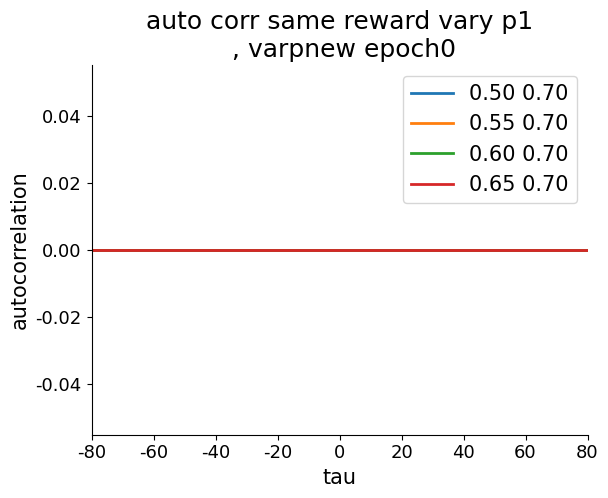

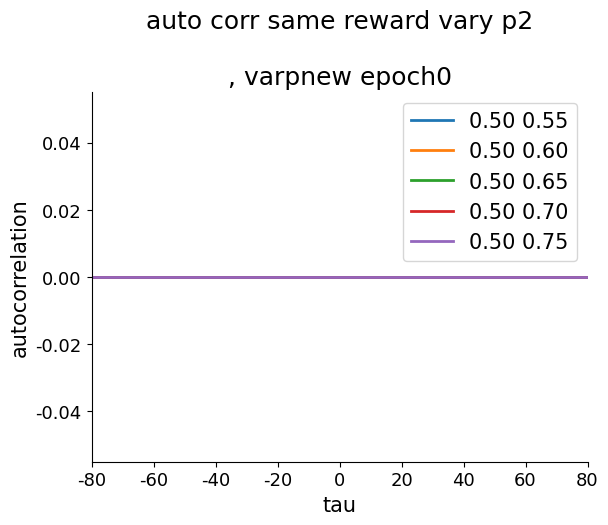

epoch 1 





/Users/yc/repo/auditory-foraging-IRC/ult.py:530: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


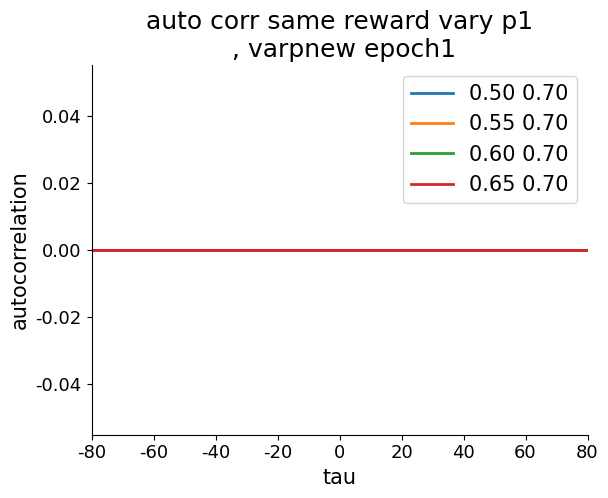

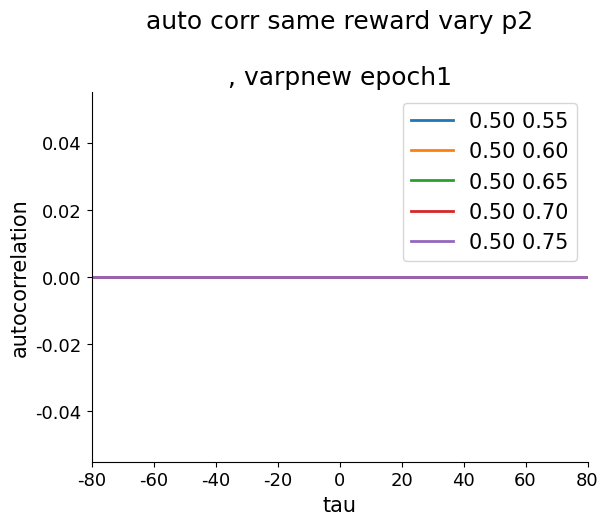

epoch 2 





/Users/yc/repo/auditory-foraging-IRC/ult.py:530: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


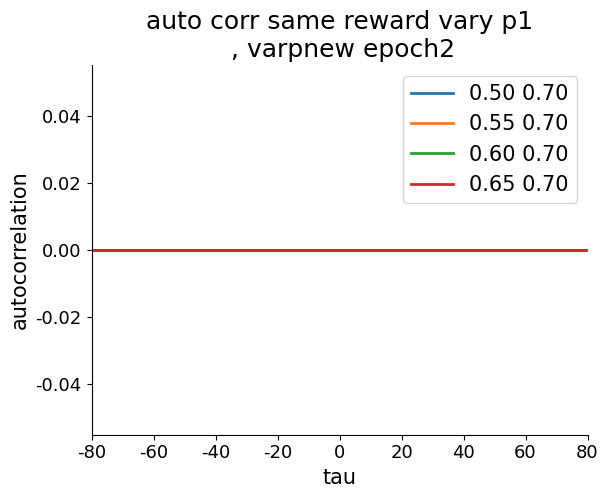

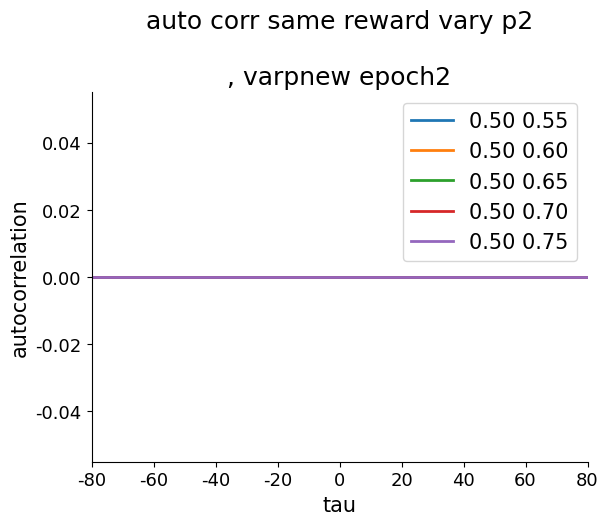

epoch 3 





/Users/yc/repo/auditory-foraging-IRC/ult.py:530: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


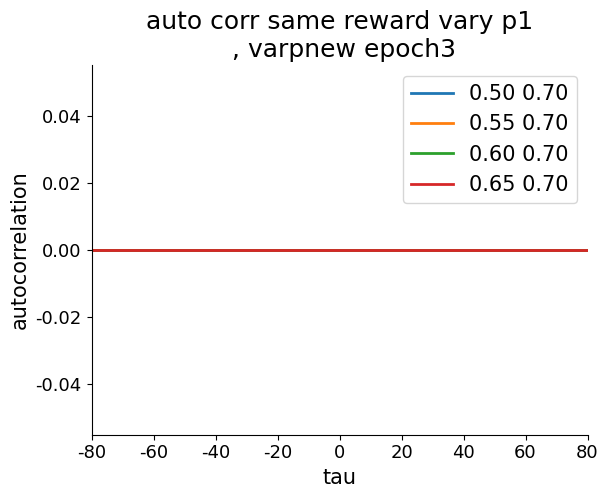

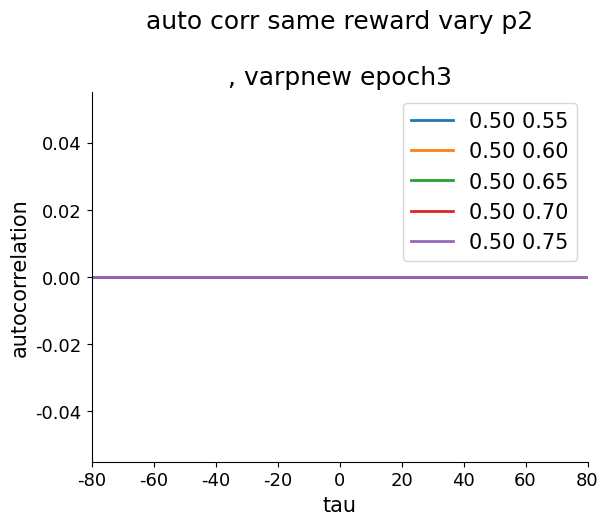

epoch 4 





/Users/yc/repo/auditory-foraging-IRC/ult.py:530: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


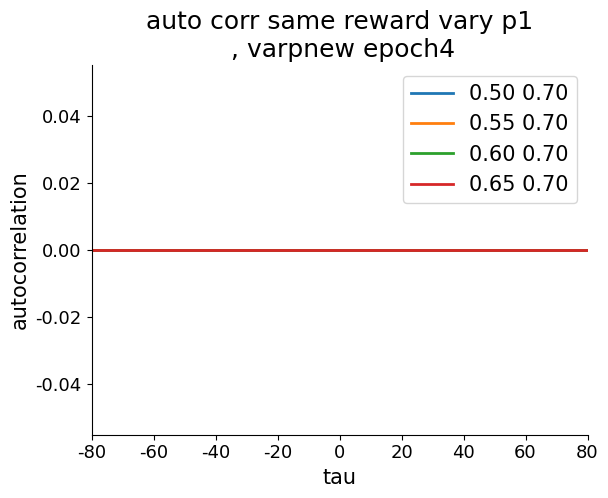

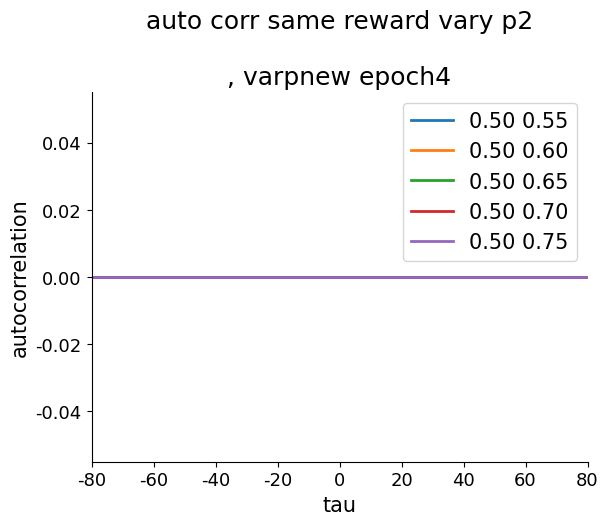

epoch 5 





/Users/yc/repo/auditory-foraging-IRC/ult.py:530: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


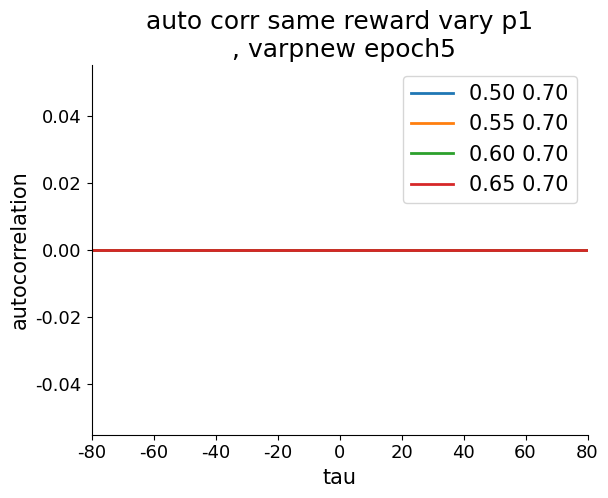

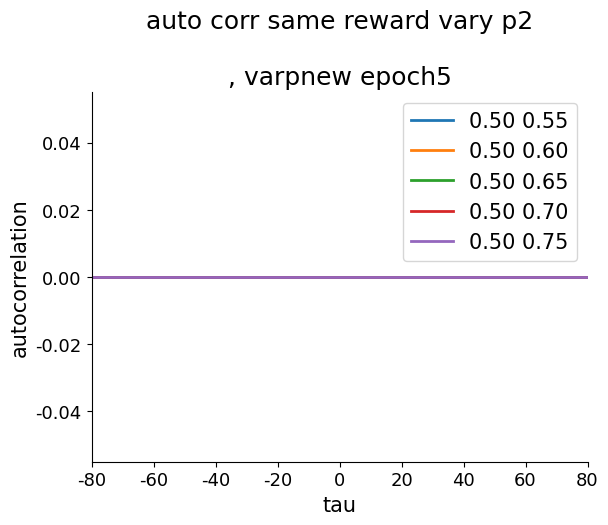

epoch 6 





/Users/yc/repo/auditory-foraging-IRC/ult.py:530: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


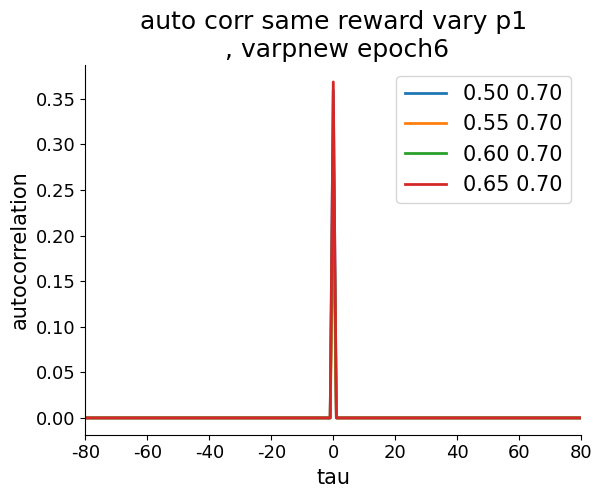

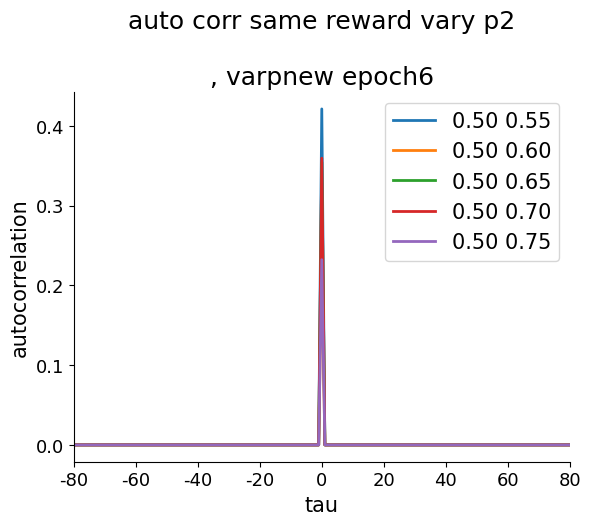

epoch 7 





/Users/yc/repo/auditory-foraging-IRC/ult.py:530: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


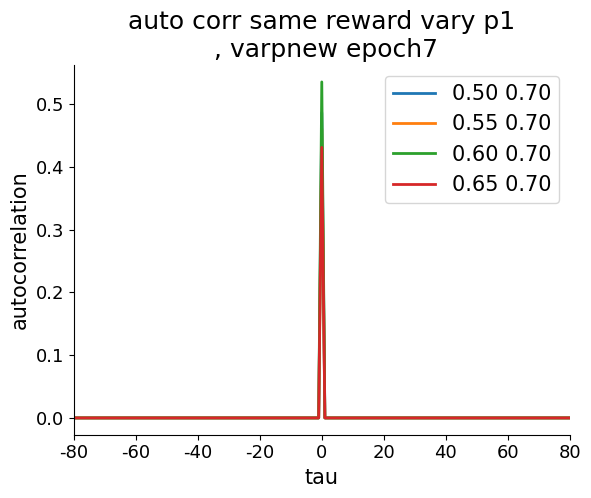

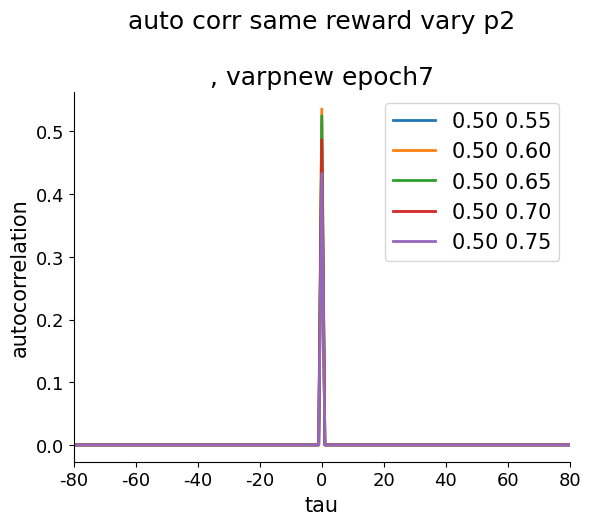

epoch 8 





/Users/yc/repo/auditory-foraging-IRC/ult.py:530: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


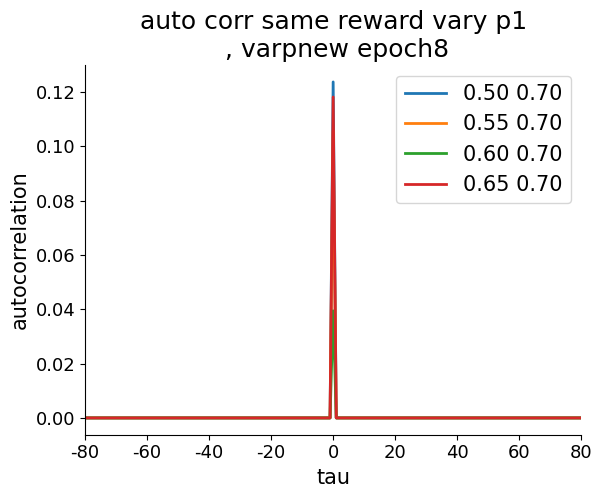

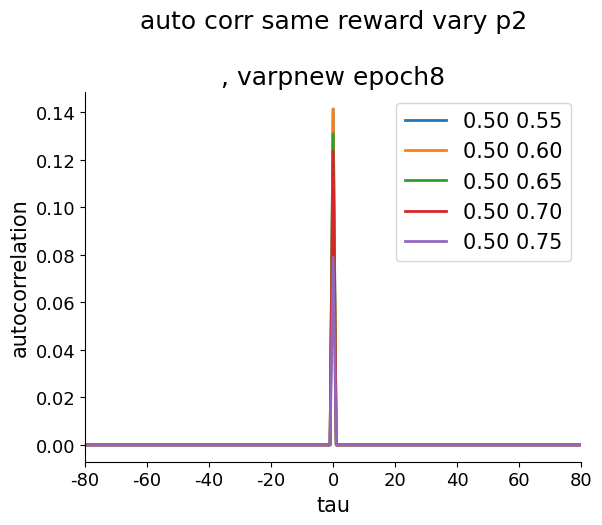

epoch 9 





/Users/yc/repo/auditory-foraging-IRC/ult.py:530: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


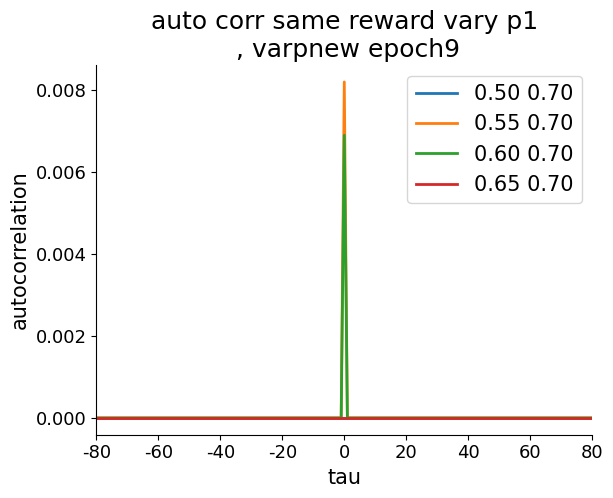

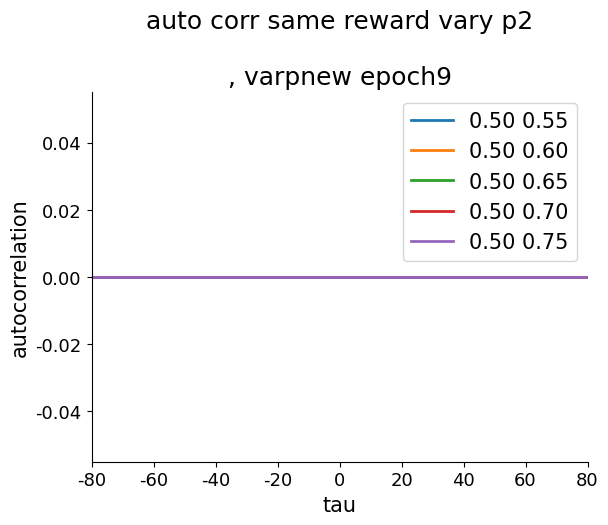

epoch 10 





/Users/yc/repo/auditory-foraging-IRC/ult.py:530: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


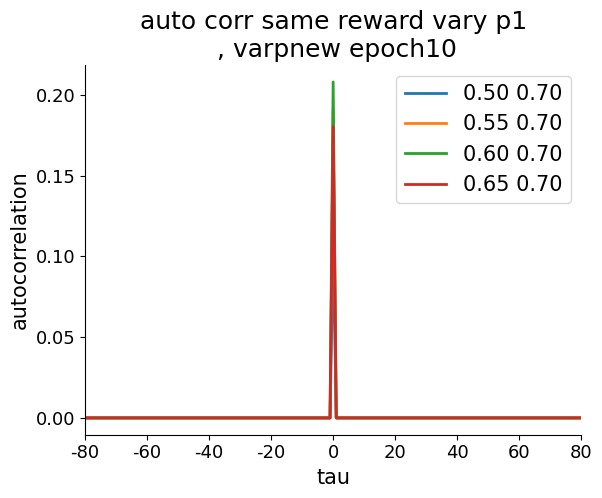

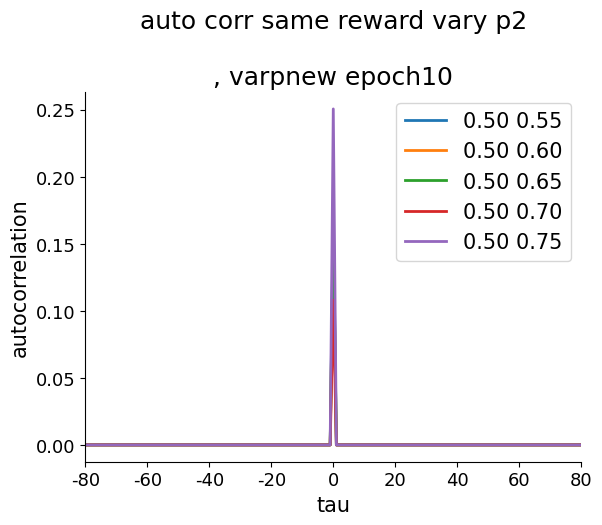

epoch 11 





KeyboardInterrupt: 

In [60]:
for e in range(n_epoch):
    print('epoch', e, '\n\n\n')
    model.learn(total_timesteps=epoch_size,
                tb_log_name=thismodel,
                reset_num_timesteps=False,
                )
    no_episodes=9999
    def eval_wrapper(a):
        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                num_steps=100000, deterministic=True)
        return episode

    with multiprocess.Pool(processes=6) as pool:
        all_episode_data = pool.map(eval_wrapper, range(no_episodes))


    # auto correlation    
    eps=0.001
    p2=0.7
    for food_reward_idx in [0]:
        for p1 in [0.5,0.55,0.6,0.65]:
            att_seq_list = []
            for episode in all_episode_data:
                # print(episode['p1p2'], p1, p2)
                if episode['trial_food_reward_idx']==food_reward_idx and p1-eps<episode['p1p2'][0]<p1+eps and p2-eps<episode['p1p2'][1]<eps+p2:
                    att_seq_list.append([float(elt[1]) for elt in episode['actions']])
                
            # Sorting based on increasing trial length
            sorted_list_of_lists = sorted(att_seq_list, key=len)
            sequences = sorted_list_of_lists[-9999:-1] # Choosing what range of trial lengths to use. Could modify to be more consistent.
            normalized_sequences = []
            max_length = 1
            for sequence in sequences:
                normalized_seq = np.array(sequence)
                if not np.isnan(normalized_seq.any()):
                    normalized_sequences.append(normalized_seq)
                    max_length = max(max_length, len(normalized_seq))    
                
            padded_sequences = []
            for seq in normalized_sequences:
                padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
                padded_sequences.append(padded_seq)

            autocorrelation_sum = np.zeros(2 * max_length - 1)
            for seq in padded_sequences:
                autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)

            average_autocorrelation = autocorrelation_sum / len(padded_sequences)
            xs=np.arange(0,len(average_autocorrelation),1)
            xs=xs-len(xs)//2
            plt.plot(xs,average_autocorrelation,label=f'{p1:.2f} {p2:.2f}')
            
        plt.xlabel('tau')
        plt.ylabel('autocorrelation')
        plt.title(f'auto corr same reward vary p1\n , {modelname} epoch{e}')
        plt.xlim(-80,80)
        plt.legend()
        # quicksave('autocorr', plotname)
        plt.show()

    # auto correlation    
    eps=0.001
    p1=0.5
    for p2 in np.arange(0.55,0.8,0.05):
        att_seq_list = []
        for episode in all_episode_data:
            # print(episode['p1p2'], p1, p2)
            if p1-eps<episode['p1p2'][0]<p1+eps and p2-eps<episode['p1p2'][1]<eps+p2:
                att_seq_list.append([float(elt[1]) for elt in episode['actions']])
            
        # Sorting based on increasing trial length
        sorted_list_of_lists = sorted(att_seq_list, key=len)
        sequences = sorted_list_of_lists[-9999:-1] # Choosing what range of trial lengths to use. Could modify to be more consistent.
        normalized_sequences = []
        max_length = 1
        for sequence in sequences:
            normalized_seq = np.array(sequence)
            if not np.isnan(normalized_seq.any()):
                normalized_sequences.append(normalized_seq)
                max_length = max(max_length, len(normalized_seq))    
        padded_sequences = []
        for seq in normalized_sequences:
            padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
            padded_sequences.append(padded_seq)

        autocorrelation_sum = np.zeros(2 * max_length - 1)
        for seq in padded_sequences:
            autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)

        average_autocorrelation = autocorrelation_sum / len(padded_sequences)
        xs=np.arange(0,len(average_autocorrelation),1)
        xs=xs-len(xs)//2
        plt.plot(xs,average_autocorrelation,label=f'{p1:.2f} {p2:.2f}')
            
    plt.xlabel('tau')
    plt.ylabel('autocorrelation')
    plt.title(f'auto corr same reward vary p2\n \n, {modelname} epoch{e}')
    plt.xlim(-80,80)
    plt.legend()
    # quicksave('autocorr', plotname)
    plt.show()